## 설치

In [ ]:
!pip uninstall -y mediapipe opencv-python opencv-python-headless opencv-contrib-python

!pip install --no-cache-dir \
    numpy==1.26.4 \
    protobuf==5.29.6 \
    opencv-contrib-python==4.11.0.86 \
    tqdm

!pip install --no-cache-dir --no-deps mediapipe==0.10.21

Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92
Found existing installation: opencv-python-headless 4.13.0.92
Uninstalling opencv-python-headless-4.13.0.92:
  Successfully uninstalled opencv-python-headless-4.13.0.92
Found existing installation: opencv-contrib-python 4.13.0.92
Uninstalling opencv-contrib-python-4.13.0.92:
  Successfully uninstalled opencv-contrib-python-4.13.0.92
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 181.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 275.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 188.4 MB/s eta 0:00:00
ERROR: Operation cancelled by user
^C


In [ ]:
import cv2
import numpy as np
import mediapipe as mp
import google.protobuf

print("cv2:", cv2.__version__)
print("numpy:", np.__version__)
print("mediapipe:", mp.__version__)
print("protobuf:", google.protobuf.__version__)

mp_pose = mp.solutions.pose
print("MediaPipe Pose import 성공")

cv2: 4.11.0
numpy: 1.26.4
mediapipe: 0.10.21
protobuf: 5.29.6
MediaPipe Pose import 성공


## 구글 드라이브 마운

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

ROOT = "/content/drive/MyDrive/salpim_project"

print(os.path.exists(ROOT))

print(os.listdir(ROOT))

True
['00_data', '01_dataset', '02_processed_frames', '01_code', '02_models', '03_outputs', '02_processed_frames_person_split', '03_rgb_features', '03_demo_videos', '03_skeleton_mediapipe_hip_body_norm_v2']


In [ ]:
TRAIN_PATH = "/content/drive/MyDrive/salpim_project/02_processed_frames_person_split/train"

print(os.path.exists(TRAIN_PATH))

print(os.listdir(TRAIN_PATH)[:10])

True
['A018', 'A016', 'A023', 'A011', 'A010', 'A054', 'A031', 'A041', 'A053', 'A035']


In [ ]:
import os

video_folders = []

for current_root, dirs, files in os.walk(TRAIN_PATH):
    if any(f.endswith(".jpg") for f in files):
        video_folders.append(current_root)

print("영상 폴더 수:", len(video_folders))
print(video_folders[:5])

영상 폴더 수: 629
['/content/drive/MyDrive/salpim_project/02_processed_frames_person_split/train/A018/A018_P211_G001_H120', '/content/drive/MyDrive/salpim_project/02_processed_frames_person_split/train/A018/A018_P201_G005_H070', '/content/drive/MyDrive/salpim_project/02_processed_frames_person_split/train/A018/A018_P220_G001_H120', '/content/drive/MyDrive/salpim_project/02_processed_frames_person_split/train/A018/A018_P205_G008_H070', '/content/drive/MyDrive/salpim_project/02_processed_frames_person_split/train/A018/A018_P226_G002_H070']


In [ ]:
import json
import cv2
import numpy as np
from tqdm import tqdm

INPUT_ROOT = "/content/drive/MyDrive/salpim_project/02_processed_frames_person_split"
OUTPUT_ROOT = "/content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

LABEL_MAP = {
    "A010": 0,
    "A011": 1,
    "A016": 2,
    "A018": 3,
    "A023": 4,
    "A031": 5,
    "A035": 6,
    "A041": 7,
    "A053": 8,
    "A054": 9,
}

SELECTED_LANDMARKS = [
    0, 11, 12, 13, 14, 15, 16,
    23, 24, 25, 26, 27, 28,
    5, 2, 7, 8
]

SEQ_LEN = 90
NUM_JOINTS = 17
NUM_FEATURES = 6
MIN_VISIBILITY = 0.3

In [ ]:
def get_image_files(folder):
    exts = (".jpg", ".jpeg", ".png", ".bmp")
    return sorted([
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith(exts)
    ])


def extract_label_from_path(path):
    parts = path.replace("\\", "/").split("/")
    for p in parts:
        if p in LABEL_MAP:
            return p
    return None


def find_video_frame_folders(root):
    video_folders = []

    for current_root, dirs, files in os.walk(root):
        has_image = any(
            f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
            for f in files
        )
        if has_image:
            video_folders.append(current_root)

    return sorted(video_folders)


def normalize_pose(landmarks):
    coords = landmarks[:, :3].astype(np.float32)
    visibility = landmarks[:, 3].astype(np.float32)

    left_hip = coords[23]
    right_hip = coords[24]
    hip_center = (left_hip + right_hip) / 2.0

    left_shoulder = coords[11]
    right_shoulder = coords[12]
    shoulder_center = (left_shoulder + right_shoulder) / 2.0

    body_scale = np.linalg.norm(shoulder_center - hip_center)

    if body_scale < 1e-6 or np.isnan(body_scale):
        body_scale = 1.0

    coords = coords - hip_center
    coords = coords / body_scale

    selected_coords = coords[SELECTED_LANDMARKS]
    selected_visibility = visibility[SELECTED_LANDMARKS]

    return selected_coords, selected_visibility


def add_velocity(sequence_xyz):
    velocity = np.zeros_like(sequence_xyz, dtype=np.float32)
    velocity[1:] = sequence_xyz[1:] - sequence_xyz[:-1]
    return np.concatenate([sequence_xyz, velocity], axis=-1).astype(np.float32)


def pad_or_sample_sequence(sequence, target_len=90):
    T = sequence.shape[0]

    if T == 0:
        return np.zeros((target_len, NUM_JOINTS, NUM_FEATURES), dtype=np.float32)

    if T == target_len:
        return sequence.astype(np.float32)

    if T > target_len:
        indices = np.linspace(0, T - 1, target_len).astype(int)
        return sequence[indices].astype(np.float32)

    pad_len = target_len - T
    padding = np.repeat(sequence[-1:], pad_len, axis=0)

    return np.concatenate([sequence, padding], axis=0).astype(np.float32)

In [ ]:
test_folder = video_folders[0]
print(test_folder)

image_files = get_image_files(test_folder)
print("프레임 수:", len(image_files))
print("첫 프레임:", image_files[0])

/content/drive/MyDrive/salpim_project/02_processed_frames_person_split/train/A018/A018_P211_G001_H120
프레임 수: 113
첫 프레임: /content/drive/MyDrive/salpim_project/02_processed_frames_person_split/train/A018/A018_P211_G001_H120/frame_0000.jpg


In [ ]:
pose_model = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=1,
    smooth_landmarks=True,
    enable_segmentation=False,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

img = cv2.imread(image_files[0])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_rgb.flags.writeable = False

result = pose_model.process(img_rgb)

print(result.pose_landmarks is not None)

pose_model.close()

True


In [ ]:
# 영상 하나 처리 함수
def process_one_video_folder(frame_folder, pose_model):
    image_files = get_image_files(frame_folder)

    sequence_xyz = []

    skipped_read_fail = 0
    skipped_no_pose = 0
    skipped_low_visibility = 0

    for img_path in image_files:
        image = cv2.imread(img_path)

        if image is None:
            skipped_read_fail += 1
            continue

        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image_rgb.flags.writeable = False

        try:
            result = pose_model.process(image_rgb)
        except Exception as e:
            skipped_no_pose += 1
            continue

        if result.pose_landmarks is None:
            skipped_no_pose += 1
            continue

        landmarks = []

        for lm in result.pose_landmarks.landmark:
            landmarks.append([
                lm.x,
                lm.y,
                lm.z,
                lm.visibility
            ])

        landmarks = np.array(landmarks, dtype=np.float32)

        selected_coords, selected_visibility = normalize_pose(landmarks)

        if np.mean(selected_visibility) < MIN_VISIBILITY:
            skipped_low_visibility += 1
            continue

        sequence_xyz.append(selected_coords)

    info = {
        "total_frames": len(image_files),
        "valid_frames_before_sampling": len(sequence_xyz),
        "skipped_read_fail": skipped_read_fail,
        "skipped_no_pose": skipped_no_pose,
        "skipped_low_visibility": skipped_low_visibility
    }

    if len(sequence_xyz) == 0:
        return None, info

    sequence_xyz = np.array(sequence_xyz, dtype=np.float32)
    sequence_6d = add_velocity(sequence_xyz)
    sequence_6d = pad_or_sample_sequence(sequence_6d, SEQ_LEN)

    return sequence_6d, info

In [ ]:
# 영상별 저장 함수
def build_split_dataset_by_file(split_name, input_root, output_root, overwrite=False):
    split_root = os.path.join(input_root, split_name)

    skeleton_output = os.path.join(output_root, split_name, "skeleton")
    os.makedirs(skeleton_output, exist_ok=True)

    meta_path = os.path.join(output_root, split_name, "meta.json")
    labels_path = os.path.join(output_root, split_name, "labels.json")

    video_folders = find_video_frame_folders(split_root)

    print(f"\n[{split_name}] 영상 폴더 수: {len(video_folders)}")
    print(f"[{split_name}] 저장 경로: {skeleton_output}")

    meta = []
    labels = {}

    pose_model = mp_pose.Pose(
        static_image_mode=False,
        model_complexity=1,
        smooth_landmarks=True,
        enable_segmentation=False,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    )

    success_count = 0
    failed_count = 0
    skipped_existing_count = 0

    try:
        for folder in tqdm(video_folders):
            label_name = extract_label_from_path(folder)

            if label_name is None:
                failed_count += 1
                meta.append({
                    "folder": folder,
                    "status": "failed",
                    "reason": "label_not_found"
                })
                continue

            video_id = os.path.basename(folder)
            save_name = f"{video_id}.npy"
            save_path = os.path.join(skeleton_output, save_name)

            if os.path.exists(save_path) and not overwrite:
                skipped_existing_count += 1
                labels[save_name] = LABEL_MAP[label_name]

                meta.append({
                    "folder": folder,
                    "file": save_name,
                    "label_name": label_name,
                    "label_id": LABEL_MAP[label_name],
                    "status": "skipped_existing"
                })
                continue

            sequence, info = process_one_video_folder(folder, pose_model)

            if sequence is None:
                failed_count += 1
                meta.append({
                    "folder": folder,
                    "file": save_name,
                    "label_name": label_name,
                    "label_id": LABEL_MAP[label_name],
                    "status": "failed",
                    "reason": "no_valid_skeleton",
                    **info
                })
                continue

            np.save(save_path, sequence)

            labels[save_name] = LABEL_MAP[label_name]
            success_count += 1

            meta.append({
                "folder": folder,
                "file": save_name,
                "label_name": label_name,
                "label_id": LABEL_MAP[label_name],
                "status": "success",
                "shape": list(sequence.shape),
                **info
            })

    finally:
        pose_model.close()

    os.makedirs(os.path.join(output_root, split_name), exist_ok=True)

    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

    with open(labels_path, "w", encoding="utf-8") as f:
        json.dump(labels, f, ensure_ascii=False, indent=2)

    summary = {
        "split": split_name,
        "total_video_folders": len(video_folders),
        "success_count": success_count,
        "failed_count": failed_count,
        "skipped_existing_count": skipped_existing_count,
        "skeleton_output": skeleton_output,
        "meta_path": meta_path,
        "labels_path": labels_path
    }

    print(f"\n[{split_name}] 처리 완료")
    print(json.dumps(summary, ensure_ascii=False, indent=2))

    return summary

In [ ]:
# 전체 split 실행 함수
def build_all_splits_by_file(input_root, output_root, overwrite=False):
    os.makedirs(output_root, exist_ok=True)

    with open(os.path.join(output_root, "label_map.json"), "w", encoding="utf-8") as f:
        json.dump(LABEL_MAP, f, ensure_ascii=False, indent=2)

    all_summary = {}

    for split in ["train", "val", "test"]:
        summary = build_split_dataset_by_file(
            split_name=split,
            input_root=input_root,
            output_root=output_root,
            overwrite=overwrite
        )
        all_summary[split] = summary

    with open(os.path.join(output_root, "summary.json"), "w", encoding="utf-8") as f:
        json.dump(all_summary, f, ensure_ascii=False, indent=2)

    print("\n전체 split 처리 완료")
    print(json.dumps(all_summary, ensure_ascii=False, indent=2))

    return all_summary

In [ ]:
# 실행
build_all_splits_by_file(
    input_root=INPUT_ROOT,
    output_root=OUTPUT_ROOT,
    overwrite=False
)


[train] 영상 폴더 수: 629
[train] 저장 경로: /content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2/train/skeleton


100%|██████████| 629/629 [14:58<00:00,  1.43s/it]



[train] 처리 완료
{
  "split": "train",
  "total_video_folders": 629,
  "success_count": 38,
  "failed_count": 0,
  "skipped_existing_count": 591,
  "skeleton_output": "/content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2/train/skeleton",
  "meta_path": "/content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2/train/meta.json",
  "labels_path": "/content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2/train/labels.json"
}

[val] 영상 폴더 수: 232
[val] 저장 경로: /content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2/val/skeleton


100%|██████████| 232/232 [57:15<00:00, 14.81s/it]



[val] 처리 완료
{
  "split": "val",
  "total_video_folders": 232,
  "success_count": 232,
  "failed_count": 0,
  "skipped_existing_count": 0,
  "skeleton_output": "/content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2/val/skeleton",
  "meta_path": "/content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2/val/meta.json",
  "labels_path": "/content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2/val/labels.json"
}

[test] 영상 폴더 수: 171
[test] 저장 경로: /content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2/test/skeleton


100%|██████████| 171/171 [36:24<00:00, 12.78s/it]


[test] 처리 완료
{
  "split": "test",
  "total_video_folders": 171,
  "success_count": 171,
  "failed_count": 0,
  "skipped_existing_count": 0,
  "skeleton_output": "/content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2/test/skeleton",
  "meta_path": "/content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2/test/meta.json",
  "labels_path": "/content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2/test/labels.json"
}

전체 split 처리 완료
{
  "train": {
    "split": "train",
    "total_video_folders": 629,
    "success_count": 38,
    "failed_count": 0,
    "skipped_existing_count": 591,
    "skeleton_output": "/content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2/train/skeleton",
    "meta_path": "/content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2/train/meta.json",
    "labels_path": "/content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2/train/labels.json"
  },

{'train': {'split': 'train',
  'total_video_folders': 629,
  'success_count': 38,
  'failed_count': 0,
  'skipped_existing_count': 591,
  'skeleton_output': '/content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2/train/skeleton',
  'meta_path': '/content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2/train/meta.json',
  'labels_path': '/content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2/train/labels.json'},
 'val': {'split': 'val',
  'total_video_folders': 232,
  'success_count': 232,
  'failed_count': 0,
  'skipped_existing_count': 0,
  'skeleton_output': '/content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2/val/skeleton',
  'meta_path': '/content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2/val/meta.json',
  'labels_path': '/content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2/val/labels.json'},
 'test': {'split': 'test',
  'total_video_folders': 1

# 전처리 결과 검증

In [ ]:
import os

print(os.listdir("/content/drive"))

['MyDrive', '.shortcut-targets-by-id', 'Shareddrives', '.Trash-0']


In [ ]:
import os

OUTPUT_ROOT = "/content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2"

print("OUTPUT_ROOT 존재:", os.path.exists(OUTPUT_ROOT))

print("\n최상위 내용:")
print(os.listdir(OUTPUT_ROOT)[:20])

OUTPUT_ROOT 존재: True

최상위 내용:
['train', 'label_map.json', 'val', 'test', 'summary.json']


In [ ]:
# 1. 파일 개수 검증
import os
import json
import numpy as np

OUTPUT_ROOT = "/content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2"

for split in ["train", "val", "test"]:
    skeleton_dir = os.path.join(OUTPUT_ROOT, split, "skeleton")
    files = [f for f in os.listdir(skeleton_dir) if f.endswith(".npy")]
    print(split, len(files))

train 629
val 232
test 171


In [ ]:
# 2. 샘플 하나 SHAPE 확인
split = "train"
skeleton_dir = os.path.join(OUTPUT_ROOT, split, "skeleton")

files = [f for f in os.listdir(skeleton_dir) if f.endswith(".npy")]
sample_path = os.path.join(skeleton_dir, files[0])

data = np.load(sample_path)

print("파일명:", files[0])
print("shape:", data.shape)
print("dtype:", data.dtype)
print("min:", data.min())
print("max:", data.max())

파일명: A010_P001_C0li_C0li.npy
shape: (90, 17, 6)
dtype: float32
min: -2.4833884
max: 2.828186


In [ ]:
# 3. 좌표와 Velocity 분리 확인
xyz = data[:, :, :3]
velocity = data[:, :, 3:]

print("xyz shape:", xyz.shape)
print("velocity shape:", velocity.shape)

print("xyz min/max:", xyz.min(), xyz.max())
print("velocity min/max:", velocity.min(), velocity.max())

xyz shape: (90, 17, 3)
velocity shape: (90, 17, 3)
xyz min/max: -2.4833884 2.828186
velocity min/max: -1.0625417 1.2781113


In [ ]:
import matplotlib.pyplot as plt

JOINT_NAMES = [
    "nose",
    "left_shoulder",
    "right_shoulder",
    "left_elbow",
    "right_elbow",
    "left_wrist",
    "right_wrist",
    "left_hip",
    "right_hip",
    "left_knee",
    "right_knee",
    "left_ankle",
    "right_ankle",
    "left_eye",
    "right_eye",
    "left_ear",
    "right_ear"
]

EDGES = [
    (13, 0), (14, 0),
    (13, 15), (14, 16),

    (1, 2),
    (1, 3), (3, 5),
    (2, 4), (4, 6),

    (1, 7), (2, 8),
    (7, 8),

    (7, 9), (9, 11),
    (8, 10), (10, 12),
]

def plot_skeleton_3d(sequence, frame_idx=30):

    xyz = sequence[frame_idx, :, :3]

    fig = plt.figure(figsize=(7,7))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(
        xyz[:,0],
        xyz[:,1],
        xyz[:,2],
        s=60
    )

    for i, j in EDGES:
        ax.plot(
            [xyz[i,0], xyz[j,0]],
            [xyz[i,1], xyz[j,1]],
            [xyz[i,2], xyz[j,2]]
        )

    # 관절 번호 표시
    for idx in range(17):
        ax.text(
            xyz[idx,0],
            xyz[idx,1],
            xyz[idx,2],
            str(idx),
            fontsize=10
        )

    ax.set_title(f"3D Skeleton - frame {frame_idx}")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    plt.show()

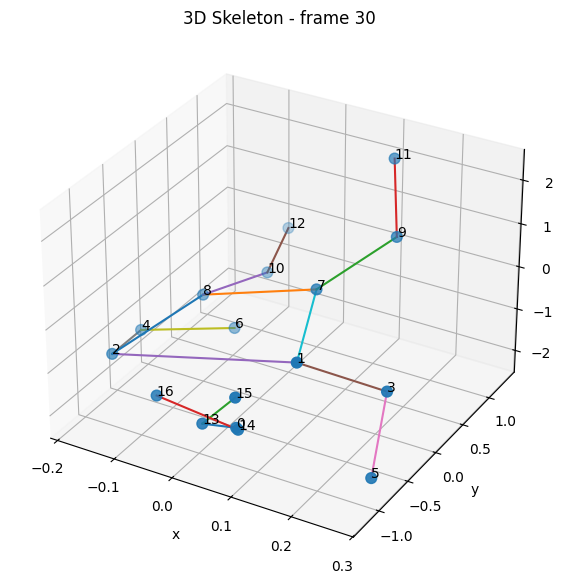

In [ ]:
plot_skeleton_3d(data, 30)

In [ ]:
## 2D 시각화 함수

import matplotlib.pyplot as plt

JOINT_NAMES = [
    "nose",
    "left_shoulder",
    "right_shoulder",
    "left_elbow",
    "right_elbow",
    "left_wrist",
    "right_wrist",
    "left_hip",
    "right_hip",
    "left_knee",
    "right_knee",
    "left_ankle",
    "right_ankle",
    "left_eye",
    "right_eye",
    "left_ear",
    "right_ear"
]

EDGES = [
    (13, 0), (14, 0),
    (13, 15), (14, 16),

    (1, 2),
    (1, 3), (3, 5),
    (2, 4), (4, 6),

    (1, 7), (2, 8),
    (7, 8),

    (7, 9), (9, 11),
    (8, 10), (10, 12),
]

def plot_skeleton_2d(sequence, frame_idx=30):

    xyz = sequence[frame_idx, :, :3]

    x = xyz[:, 0]
    y = -xyz[:, 1]   # 화면처럼 보기 위해 y축 반전

    plt.figure(figsize=(6, 8))

    plt.scatter(x, y, s=60)

    for i, j in EDGES:
        plt.plot(
            [x[i], x[j]],
            [y[i], y[j]]
        )

    for idx in range(17):
        plt.text(
            x[idx],
            y[idx],
            str(idx),
            fontsize=10
        )

    plt.title(f"2D Skeleton - frame {frame_idx}")
    plt.xlabel("x")
    plt.ylabel("-y")

    plt.axis("equal")
    plt.grid(True)

    plt.show()

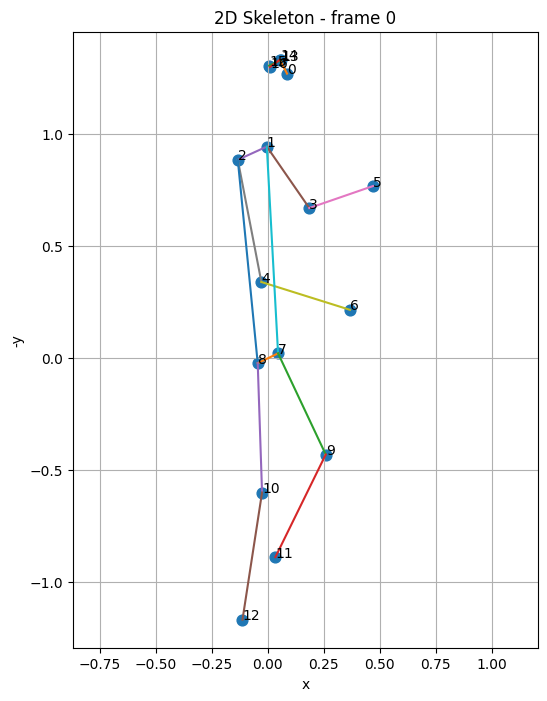

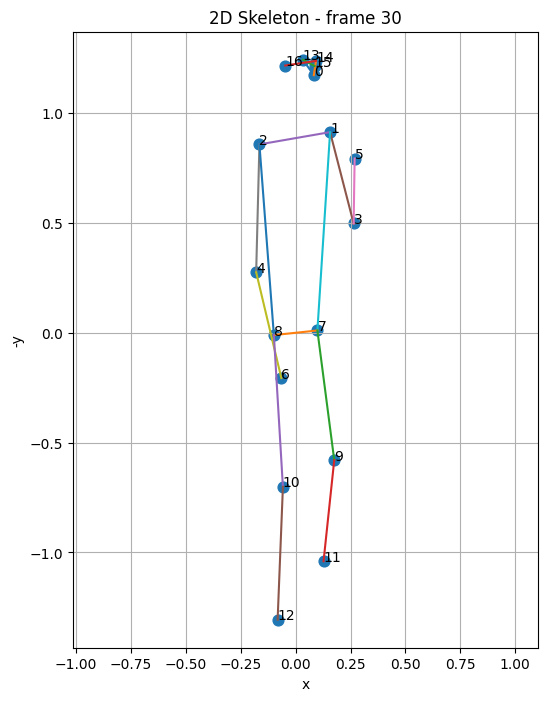

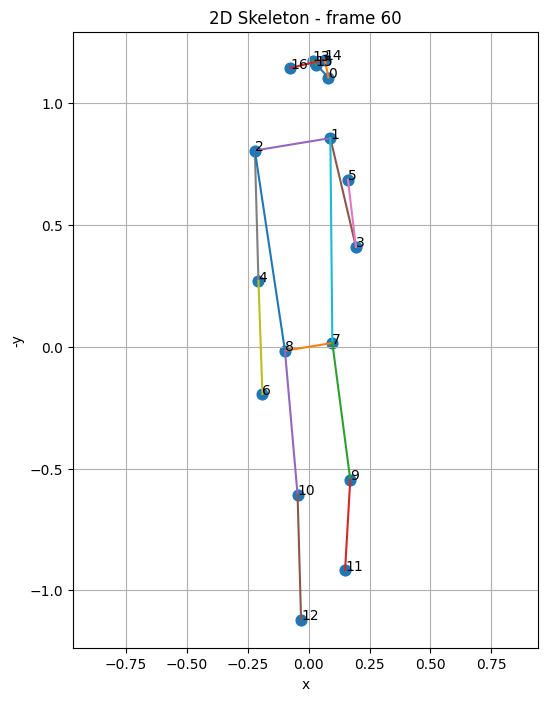

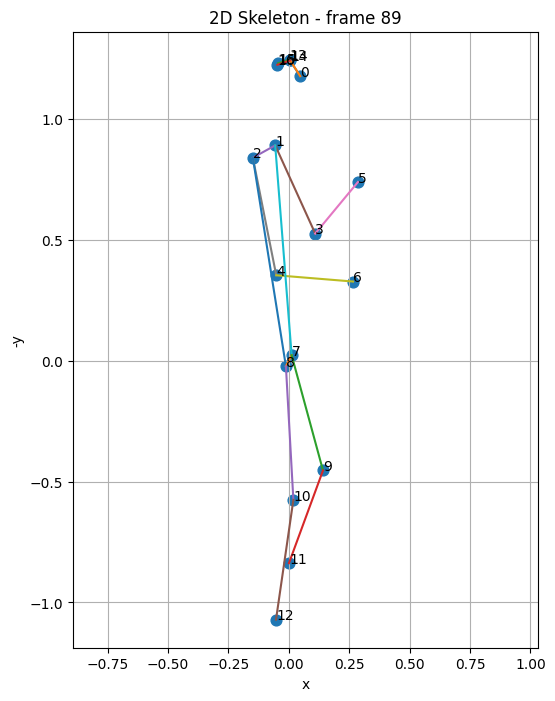

In [ ]:
## 특정 프레임 확인

plot_skeleton_2d(data, frame_idx=0)
plot_skeleton_2d(data, frame_idx=30)
plot_skeleton_2d(data, frame_idx=60)
plot_skeleton_2d(data, frame_idx=89)

In [ ]:
## 쓰러지기(A053) 샘플 확인

import os
import numpy as np

skeleton_dir = "/content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2/train/skeleton"

a053_files = [
    f for f in os.listdir(skeleton_dir)
    if f.startswith("A053")
]

print("A053 개수:", len(a053_files))

sample_file = a053_files[0]
print("선택 파일:", sample_file)

data = np.load(os.path.join(skeleton_dir, sample_file))

A053 개수: 57
선택 파일: A053_P001_C0li_C0li.npy


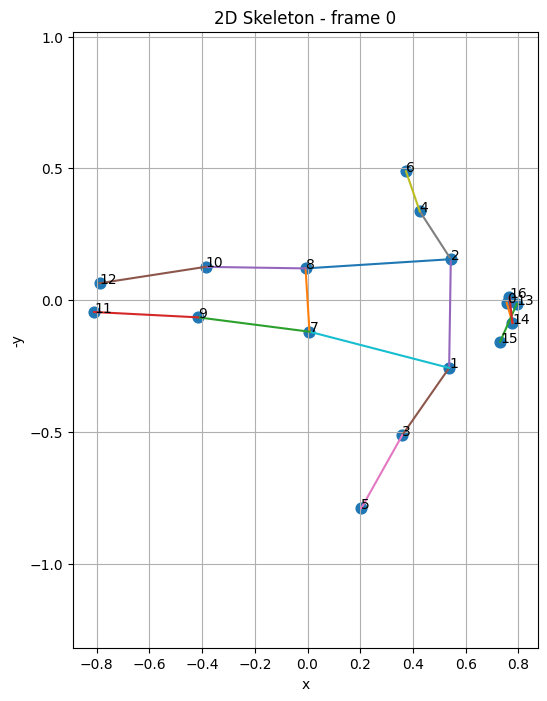

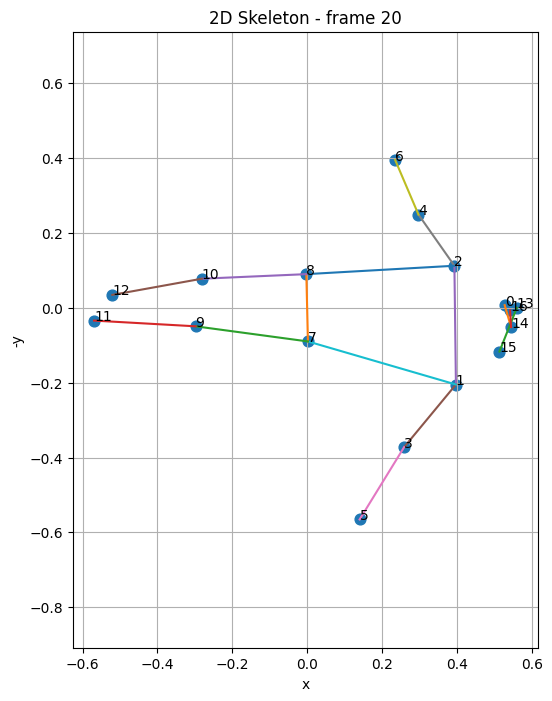

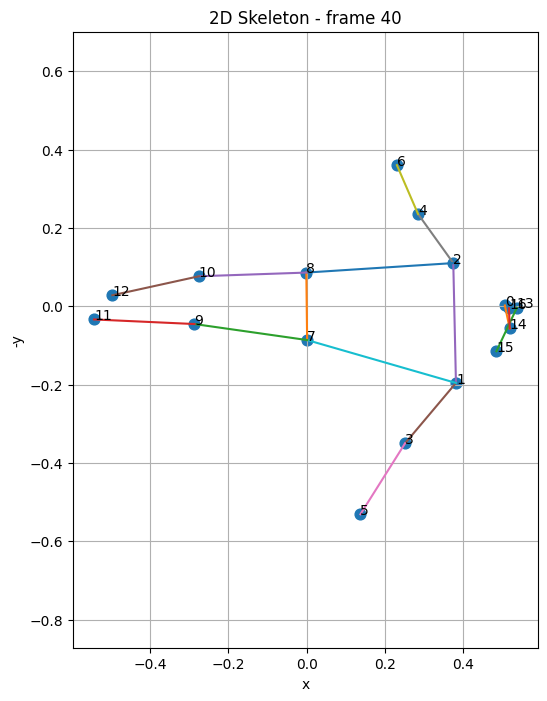

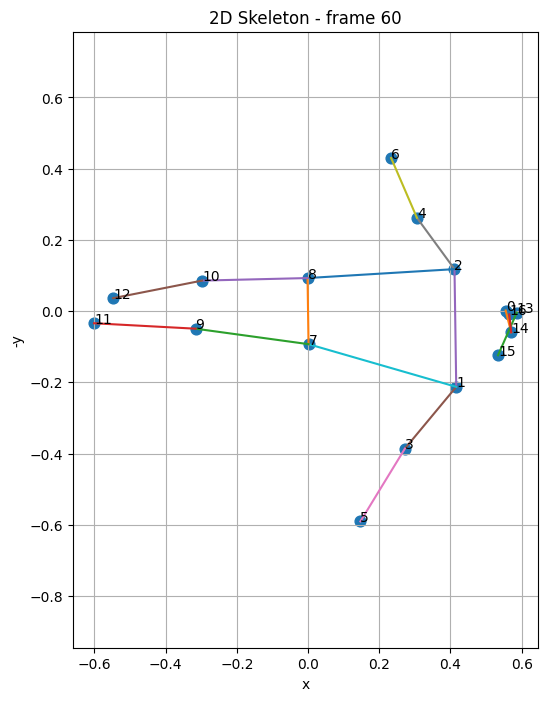

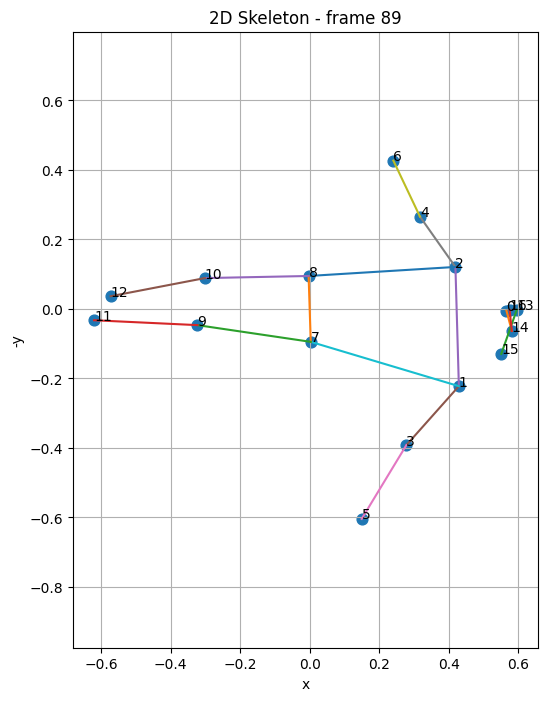

In [ ]:
plot_skeleton_2d(data, 0)
plot_skeleton_2d(data, 20)
plot_skeleton_2d(data, 40)
plot_skeleton_2d(data, 60)
plot_skeleton_2d(data, 89)

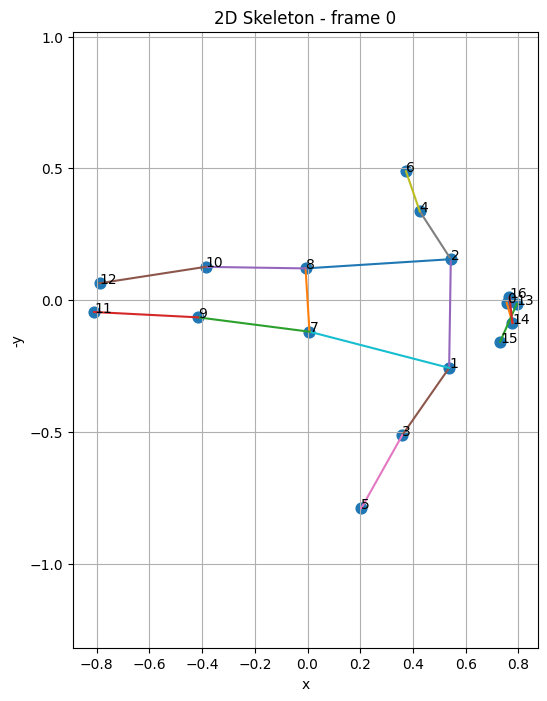

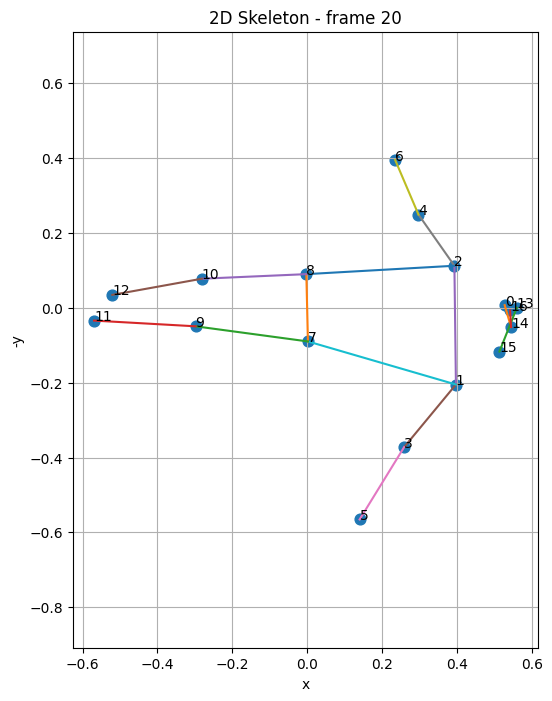

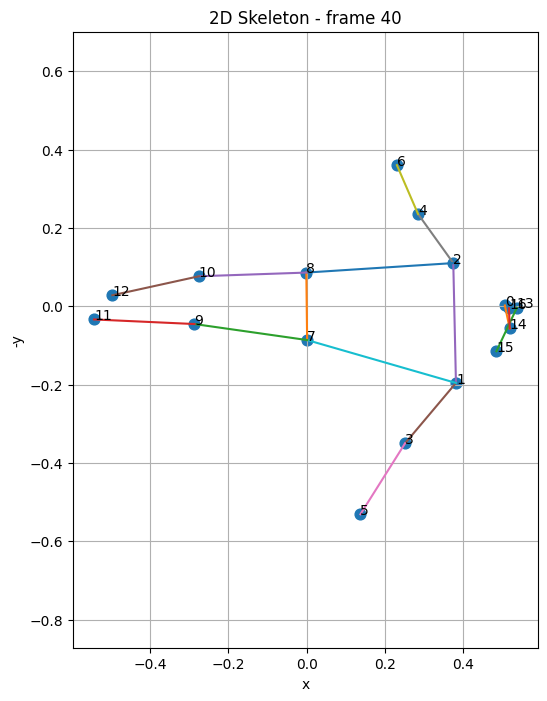

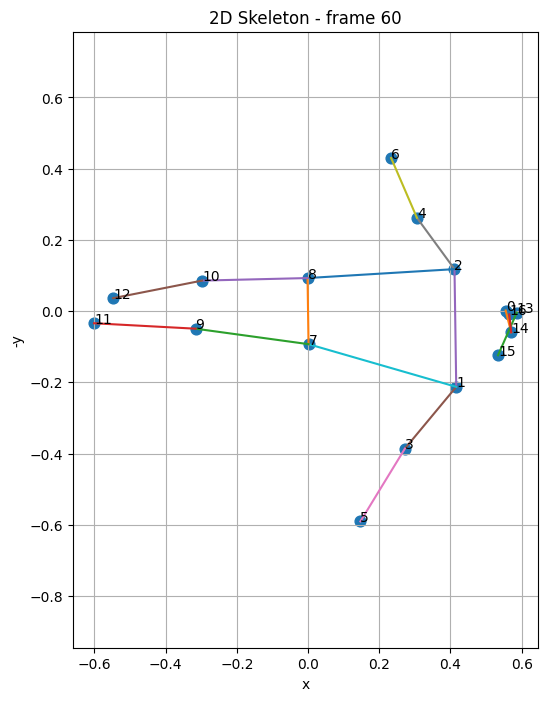

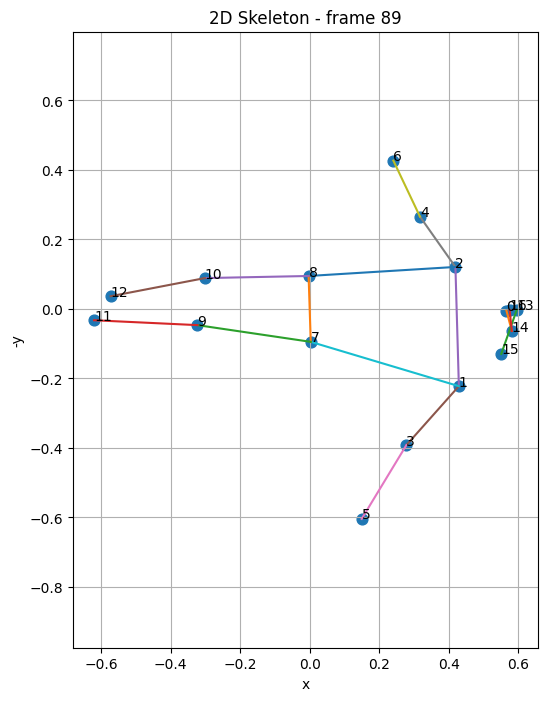

In [ ]:
frames = [0, 20, 40, 60, 89]

for f in frames:
    plot_skeleton_2d(data, f)

A023_P001_C0li_C0li.npy (90, 17, 6) -1.9593616 2.0095818


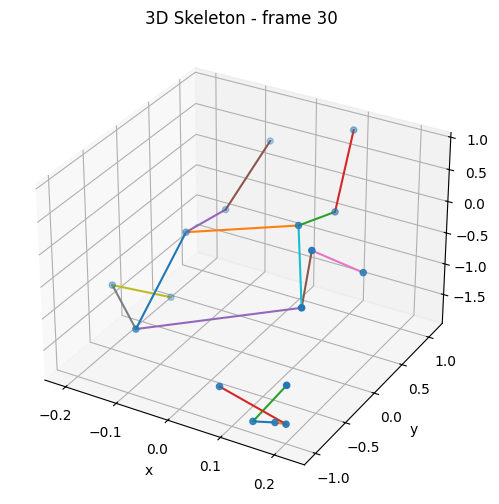

A054_P205_G007_H070.npy (90, 17, 6) -3.1270368 2.5263178


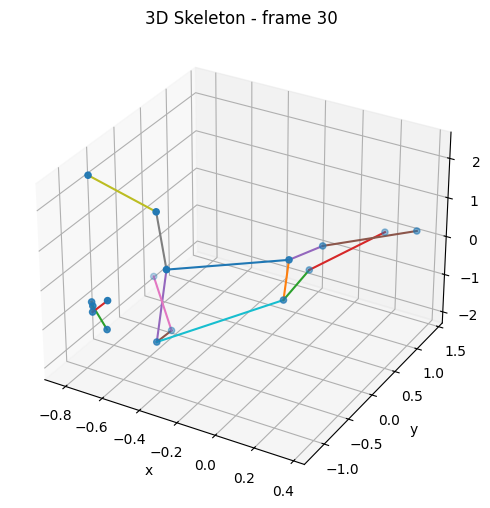

A016_P223_G001_H070.npy (90, 17, 6) -3.2557862 3.9750838


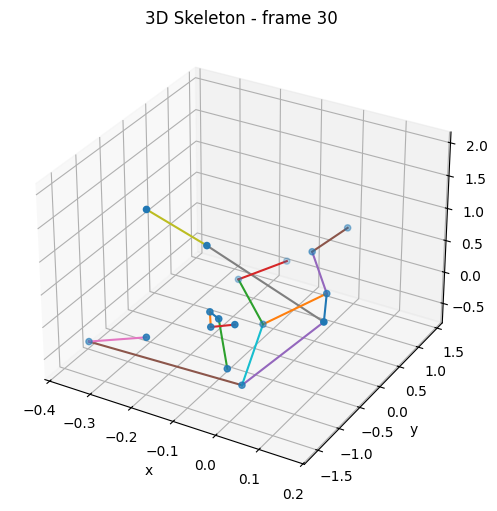

In [ ]:
# 5. 여러 샘플 랜덤 확인
import random

for _ in range(3):
    file = random.choice(files)
    sample = np.load(os.path.join(skeleton_dir, file))
    print(file, sample.shape, sample.min(), sample.max())
    plot_skeleton_3d(sample, frame_idx=30)

In [ ]:
# NaN 확인
for split in ["train", "val", "test"]:
    skeleton_dir = os.path.join(OUTPUT_ROOT, split, "skeleton")
    files = [f for f in os.listdir(skeleton_dir) if f.endswith(".npy")]

    nan_count = 0

    for f in files:
        arr = np.load(os.path.join(skeleton_dir, f))
        if np.isnan(arr).any():
            nan_count += 1

    print(split, "NaN 포함 파일 수:", nan_count)

train NaN 포함 파일 수: 0
val NaN 포함 파일 수: 0
test NaN 포함 파일 수: 0


## 통합 데이터셋 만들기

In [ ]:
# 통합 데이터셋 저장 경로 설정
import os
import json
import numpy as np
from tqdm import tqdm

# 영상별 skeleton npy가 저장된 경로
SKELETON_ROOT = "/content/drive/MyDrive/salpim_project/03_skeleton_mediapipe_hip_body_norm_v2"

# 통합 데이터셋 저장 경로
DATASET_ROOT = "/content/drive/MyDrive/salpim_project/04_skeleton_dataset_hip_body_norm"

os.makedirs(DATASET_ROOT, exist_ok=True)

LABEL_MAP = {
    "A010": 0,
    "A011": 1,
    "A016": 2,
    "A018": 3,
    "A023": 4,
    "A031": 5,
    "A035": 6,
    "A041": 7,
    "A053": 8,
    "A054": 9,
}

In [ ]:
# 클래스 라벨 추출 함수

def extract_label_from_filename(filename):
    label_name = filename.split("_")[0]

    if label_name not in LABEL_MAP:
        return None, None

    return label_name, LABEL_MAP[label_name]

In [ ]:
# split별 통합 함수

def build_integrated_split(split_name, skeleton_root, dataset_root):
    skeleton_dir = os.path.join(skeleton_root, split_name, "skeleton")

    if not os.path.exists(skeleton_dir):
        raise FileNotFoundError(f"Skeleton folder not found: {skeleton_dir}")

    files = sorted([
        f for f in os.listdir(skeleton_dir)
        if f.endswith(".npy")
    ])

    print(f"\n[{split_name}] skeleton 파일 수: {len(files)}")

    X = []
    y = []
    meta = []

    for filename in tqdm(files):
        label_name, label_id = extract_label_from_filename(filename)

        if label_name is None:
            print(f"[라벨 추출 실패] {filename}")
            continue

        file_path = os.path.join(skeleton_dir, filename)
        arr = np.load(file_path)

        if arr.shape != (90, 17, 6):
            print(f"[shape 이상] {filename}: {arr.shape}")
            continue

        if np.isnan(arr).any():
            print(f"[NaN 포함] {filename}")
            continue

        X.append(arr.astype(np.float32))
        y.append(label_id)

        meta.append({
            "filename": filename,
            "label_name": label_name,
            "label_id": label_id,
            "shape": list(arr.shape)
        })

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)

    split_output = os.path.join(dataset_root, split_name)
    os.makedirs(split_output, exist_ok=True)

    np.save(os.path.join(split_output, f"X_{split_name}.npy"), X)
    np.save(os.path.join(split_output, f"y_{split_name}.npy"), y)

    with open(os.path.join(split_output, f"meta_{split_name}.json"), "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

    print(f"[{split_name}] 저장 완료")
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("label count:", np.unique(y, return_counts=True))

    return X, y, meta

In [ ]:
# 전체 split 통합 실행

def build_integrated_dataset(skeleton_root, dataset_root):
    os.makedirs(dataset_root, exist_ok=True)

    with open(os.path.join(dataset_root, "label_map.json"), "w", encoding="utf-8") as f:
        json.dump(LABEL_MAP, f, ensure_ascii=False, indent=2)

    summary = {}

    for split in ["train", "val", "test"]:
        X, y, meta = build_integrated_split(split, skeleton_root, dataset_root)

        unique, counts = np.unique(y, return_counts=True)

        summary[split] = {
            "X_shape": list(X.shape),
            "y_shape": list(y.shape),
            "class_distribution": {
                str(int(k)): int(v) for k, v in zip(unique, counts)
            }
        }

    with open(os.path.join(dataset_root, "summary.json"), "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    print("\n전체 통합 완료")
    print(json.dumps(summary, ensure_ascii=False, indent=2))

In [ ]:
build_integrated_dataset(
    skeleton_root=SKELETON_ROOT,
    dataset_root=DATASET_ROOT
)


[train] skeleton 파일 수: 629


100%|██████████| 629/629 [00:06<00:00, 101.40it/s]


[train] 저장 완료
X shape: (629, 90, 17, 6)
y shape: (629,)
label count: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([62, 65, 62, 72, 59, 60, 69, 65, 57, 58]))

[val] skeleton 파일 수: 232


100%|██████████| 232/232 [00:01<00:00, 177.10it/s]


[val] 저장 완료
X shape: (232, 90, 17, 6)
y shape: (232,)
label count: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([21, 25, 27, 27, 22, 23, 18, 22, 24, 23]))

[test] skeleton 파일 수: 171


100%|██████████| 171/171 [00:00<00:00, 182.83it/s]


[test] 저장 완료
X shape: (171, 90, 17, 6)
y shape: (171,)
label count: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([16, 14, 19, 22, 18, 21, 14, 11, 19, 17]))

전체 통합 완료
{
  "train": {
    "X_shape": [
      629,
      90,
      17,
      6
    ],
    "y_shape": [
      629
    ],
    "class_distribution": {
      "0": 62,
      "1": 65,
      "2": 62,
      "3": 72,
      "4": 59,
      "5": 60,
      "6": 69,
      "7": 65,
      "8": 57,
      "9": 58
    }
  },
  "val": {
    "X_shape": [
      232,
      90,
      17,
      6
    ],
    "y_shape": [
      232
    ],
    "class_distribution": {
      "0": 21,
      "1": 25,
      "2": 27,
      "3": 27,
      "4": 22,
      "5": 23,
      "6": 18,
      "7": 22,
      "8": 24,
      "9": 23
    }
  },
  "test": {
    "X_shape": [
      171,
      90,
      17,
      6
    ],
    "y_shape": [
      171
    ],
    "class_distribution": {
      "0": 16,
      "1": 14,
      "2": 19,
      "3": 22,
      "4": 18,
      "5": 21,
      "6":

In [ ]:
# 결과 확인

for split in ["train", "val", "test"]:
    X_path = os.path.join(DATASET_ROOT, split, f"X_{split}.npy")
    y_path = os.path.join(DATASET_ROOT, split, f"y_{split}.npy")

    X = np.load(X_path)
    y = np.load(y_path)

    print(split)
    print("X:", X.shape)
    print("y:", y.shape)
    print("class count:", np.unique(y, return_counts=True))
    print()

train
X: (629, 90, 17, 6)
y: (629,)
class count: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([62, 65, 62, 72, 59, 60, 69, 65, 57, 58]))

val
X: (232, 90, 17, 6)
y: (232,)
class count: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([21, 25, 27, 27, 22, 23, 18, 22, 24, 23]))

test
X: (171, 90, 17, 6)
y: (171,)
class count: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([16, 14, 19, 22, 18, 21, 14, 11, 19, 17]))

